# Predicting EV Charging Stations for DC Fast Charging Upgrades Using Machine Learning

## Research Question
Which non-DC-Fast EV charging stations are the best candidates for a DCFC upgrade, and how do we rank them by potential impact?

## Dataset - How to Download
Using the Alternative Fueling Stations dataset from the US DOE (AFDC).

1. Go to: <https://afdc.energy.gov/data_downloadt>
2. Click **Dataset** and select "Alternative Fuel Stations" from the drop down.
3. Give basic information like name and email, as we are downloading the data from government website.
4. Click download and save the file in the same folder as this notebook
5. Rename it to: `alt_fuel_stations.csv`

87,150 rows and 75 columns — one row per US alternative fueling station.

## Phase 1 - Setup

In [263]:
# uncomment and run once to install all dependencies
# !pip install -r requirements.txt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from pathlib import Path
from datetime import date

# sklearn
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# xgboost & shap
from xgboost import XGBClassifier
import shap

# paths
DATA_DIR   = Path('.')
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# auto-detect the dataset file so it works with any download date
_csv_matches = sorted(DATA_DIR.glob('alt_fuel_stations*.csv'))
if not _csv_matches:
    raise FileNotFoundError(
        'Dataset not found. Download from https://afdc.energy.gov/stations '
        'and save as alt_fuel_stations*.csv in this directory.'
    )
CSV_FILE = _csv_matches[-1]
print(f'Using dataset: {CSV_FILE.name}')

# setting a fixed random seed so results are reproducible every run
SEED = 42
np.random.seed(SEED)

# setting seaborn theme once here so all the plots look consistent
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

print('All imports successful.')

## Phase 2 - Data Loading and EDA

In [265]:
# loading the dataset - it's large so using low_memory=False to avoid dtype warnings
raw = pd.read_csv(CSV_FILE, low_memory=False)
print(f'Raw dataset shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
raw.head(3)

Raw dataset shape: 87,150 rows x 75 columns


,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,RD Blends,RD Blends (French),RD Blended with Biodiesel,RD Maximum Biodiesel Level,NPS Unit Name,CNG Station Sells Renewable Natural Gas,LNG Station Sells Renewable Natural Gas,Maximum Vehicle Class,EV Workplace Charging,Funding Sources
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,NaN,Sun Valley,CA,91352.0,NaN,NaN,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MD,True,NaN
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015.0,NaN,213-741-1151,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,False,NaN
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Across Hope,Los Angeles,CA,90012.0,NaN,NaN,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,True,NaN


In [266]:
# the raw file has multiple fuel types - keeping only EV stations here
df = raw[raw['Fuel Type Code'] == 'ELEC'].copy().reset_index(drop=True)
print(f'EV-only stations: {len(df):,} rows')

EV-only stations: 87,150 rows


In [267]:
# looking at the columns I actually care about for modeling
cols_of_interest = [
    'EV Level1 EVSE Num', 'EV Level2 EVSE Num', 'EV DC Fast Count',
    'EV Network', 'Facility Type', 'Open Date',
    'Latitude', 'Longitude', 'State', 'Funding Sources',
    'Access Code', 'EV Connector Types'
]
df[cols_of_interest].info()
print()
df[cols_of_interest].describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87150 entries, 0 to 87149
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EV Level1 EVSE Num  682 non-null    float64
 1   EV Level2 EVSE Num  72681 non-null  float64
 2   EV DC Fast Count    15641 non-null  float64
 3   EV Network          87137 non-null  object 
 4   Facility Type       22622 non-null  object 
 5   Open Date           86617 non-null  object 
 6   Latitude            87150 non-null  float64
 7   Longitude           87150 non-null  float64
 8   State               87150 non-null  object 
 9   Funding Sources     207 non-null    object 
 10  Access Code         87150 non-null  object 
 11  EV Connector Types  87133 non-null  object 
dtypes: float64(5), object(7)
memory usage: 8.0+ MB



,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,Latitude,Longitude
count,682.00,72681.00,15641.00,87150.00,87150.00
mean,4.40,2.82,4.71,37.97,-96.13
std,8.58,4.92,5.55,5.08,19.44
min,1.00,1.00,1.00,18.00,-176.64
25%,1.00,2.00,1.00,34.05,-117.87
50%,2.00,2.00,3.00,38.65,-90.34
75%,4.00,2.00,6.00,41.73,-78.65
max,90.00,379.00,120.00,64.85,-65.65


In [268]:
# checking how much data is missing per column - some are almost entirely empty
null_pct = (df[cols_of_interest].isnull().mean() * 100).sort_values(ascending=False)
print('Missing values (%):\n')
print(null_pct.round(1).to_string())

Missing values (%):

Funding Sources       99.8
EV Level1 EVSE Num    99.2
EV DC Fast Count      82.1
Facility Type         74.0
EV Level2 EVSE Num    16.6
Open Date              0.6
EV Connector Types     0.0
EV Network             0.0
Longitude              0.0
Latitude               0.0
State                  0.0
Access Code            0.0


**How I handled the missing data**

| Column | Missing | What I did |
|--------|---------|------------|
| `Funding Sources` | 99.8% | dropped it — basically no data there |
| `EV Level1 EVSE Num` | 99.2% | folded into `total_ports` (Level1 + Level2) |
| `EV DC Fast Count` | 82.1% | null → 0 (no DCFC); this is what the target is built from |
| `Facility Type` | 74.0% | filled with `"Unknown"` before encoding as 74% unknown means this feature probably isn't doing much |
| `EV Level2 EVSE Num` | 16.6% | filled with 0, then added into `total_ports` |
| `Open Date` | 0.6% | missing station age gets filled with the median during modeling |

Only doing anything about the columns that would actually affect the analysis left the rest alone.

### 2A - NumPy Numerical Summaries

Before any plotting, I'm using NumPy directly to compute summary stats on the raw arrays. This just gives me more control over exactly which percentiles and metrics I want to look at before I decide how to handle them in feature engineering.

In [269]:
# pulling the key numerical columns out as numpy arrays so I can use np functions directly
lv1  = df['EV Level1 EVSE Num'].fillna(0).values
lv2  = df['EV Level2 EVSE Num'].fillna(0).values
dcf  = df['EV DC Fast Count'].fillna(0).values
lat  = df['Latitude'].values
lon  = df['Longitude'].values

numeric_arrays = {
    'Level1 EVSE Count': lv1,
    'Level2 EVSE Count': lv2,
    'DC Fast Count':     dcf,
    'Latitude':          lat,
    'Longitude':         lon,
}

print(f"{'Column':<22} {'Mean':>8} {'Std':>8} {'P25':>8} {'Median':>8} {'P75':>8}")
print('-' * 70)
for name, arr in numeric_arrays.items():
    print(f"{name:<22} {np.mean(arr):>8.2f} {np.std(arr):>8.2f} "
          f"{np.percentile(arr,25):>8.2f} {np.median(arr):>8.2f} {np.percentile(arr,75):>8.2f}")

# checking what fraction of stations have at least one port of each charging level
print(f"\nLevel-1 presence : {(lv1 > 0).mean()*100:.1f}%")
print(f"Level-2 presence : {(lv2 > 0).mean()*100:.1f}%")
print(f"DC Fast presence : {(dcf > 0).mean()*100:.1f}%")

Column                     Mean      Std      P25   Median      P75
----------------------------------------------------------------------
Level1 EVSE Count          0.03     0.85     0.00     0.00     0.00
Level2 EVSE Count          2.36     4.61     1.00     2.00     2.00
DC Fast Count              0.84     2.97     0.00     0.00     0.00
Latitude                  37.97     5.08    34.05    38.65    41.73
Longitude                -96.13    19.44  -117.87   -90.34   -78.65

Level-1 presence : 0.8%
Level-2 presence : 83.4%
DC Fast presence : 17.9%


82.1% of stations have no DC Fast at all; basically, the whole dataset is Level-2 only. DC Fast only shows up at 17.9%, which creates a significant class imbalance. Level-1 chargers are almost nonexistent (under 1%), so they don't really affect port totals.

### 2B - Target Variable

Creating a binary target: `has_dcfast = 1` if a station has any DC Fast ports, else 0. Need to see the actual class split before deciding how to handle the imbalance in modeling.

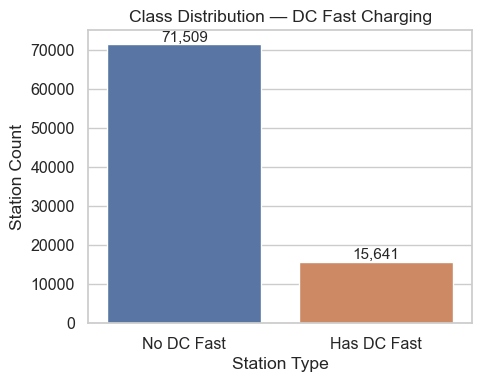

In [270]:
# creating the binary target variable - 1 if any DC Fast ports, 0 otherwise
df['has_dcfast'] = (df['EV DC Fast Count'].fillna(0) > 0).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(
    x=df['has_dcfast'].map({0: 'No DC Fast', 1: 'Has DC Fast'}),
    order=['No DC Fast', 'Has DC Fast'],
    palette=['#4C72B0', '#DD8452'],
    ax=ax
)
ax.set_title('Class Distribution — DC Fast Charging')
ax.set_xlabel('Station Type')
ax.set_ylabel('Station Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

15,641 stations (17.9%) have DC Fast and 71,509 (82.1%) don't; that's a 4.6:1 imbalance. If I don't fix this, the model would just predict "No DCFC" for everything and still hit 82.1% accuracy, which is completely useless for what I'm trying to do. I'm using SMOTE to balance the classes but applying it only inside each CV fold so the validation scores don't get inflated by synthetic data leaking into the validation set.

### 2C - Station Age Distribution

Computing station age before formal feature engineering. Want to see the distribution shape and figure out how to handle the missing values before I use it as a feature.

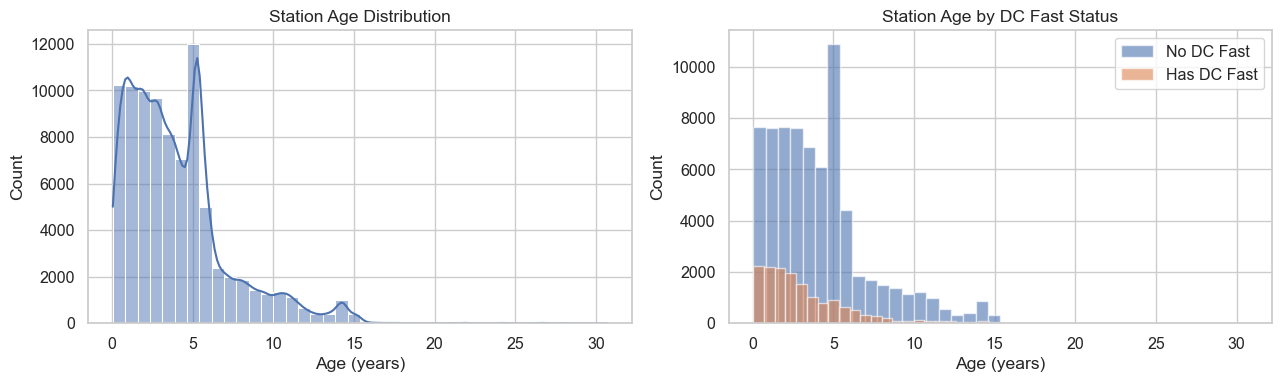

Age stats: mean=4.0y  median=3.4y  std=3.1y


In [271]:
# parsing the open date to get station age in years from today
open_date_eda = pd.to_datetime(df['Open Date'], errors='coerce')
TODAY         = pd.Timestamp(date.today())
age_eda       = ((TODAY - open_date_eda).dt.days / 365.25).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# plotting the overall age distribution to see the shape
sns.histplot(age_eda, bins=40, kde=True, color='#4C72B0', ax=axes[0])
axes[0].set_title('Station Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# splitting by DC Fast status to see if older stations skew one way
age_df = pd.DataFrame({'age': age_eda, 'has_dcfast': df.loc[age_eda.index, 'has_dcfast']})
for val, label, color in [(0,'No DC Fast','#4C72B0'),(1,'Has DC Fast','#DD8452')]:
    subset = age_df[age_df['has_dcfast']==val]['age']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title('Station Age by DC Fast Status')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Age stats: mean={age_eda.mean():.1f}y  median={age_eda.median():.1f}y  std={age_eda.std():.1f}y')

Most stations opened in the last 6 years, which tracks with how fast EV infrastructure grew in the early 2020s. DC Fast stations tend to be slightly older on average since early EV builds focused on highway corridors. This is part of why older non-DCFC stations are interesting upgrade candidates — they've been sitting there without an upgrade for longer, and why `station_age_years` goes into the priority score.

### 2D - Level-2 Port Count Distribution

Port count is very right-skewed (a few hubs have way more ports than everything else), so clipping at the 99th percentile (19 ports) to make the histogram actually readable.

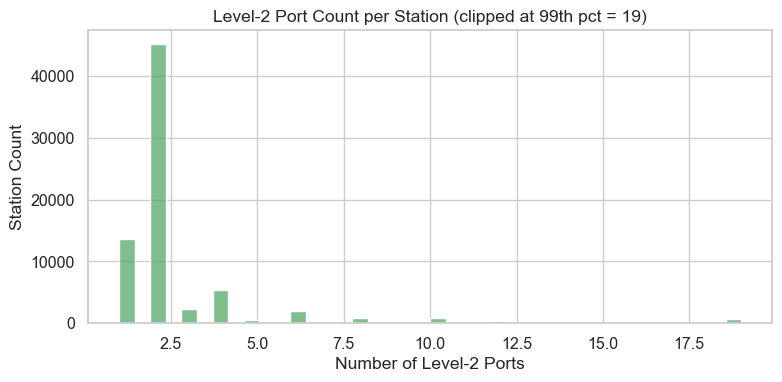

Mean: 2.82  |  Median: 2.00  |  p99: 19


In [272]:
lv2_nonzero = df['EV Level2 EVSE Num'].dropna()
p99 = np.percentile(lv2_nonzero, 99)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(lv2_nonzero.clip(upper=p99), bins=40, kde=False, color='#55A868', ax=ax)
ax.set_title(f'Level-2 Port Count per Station (clipped at 99th pct = {p99:.0f})')
ax.set_xlabel('Number of Level-2 Ports')
ax.set_ylabel('Station Count')
plt.tight_layout()
plt.show()

print(f'Mean: {np.mean(lv2_nonzero):.2f}  |  Median: {np.median(lv2_nonzero):.2f}  |  p99: {p99:.0f}')

Most stations have 2–3 Level-2 ports (mean 2.82, median 2.0). A small number of high-traffic hubs have 20+. Stations with more ports are already serving more demand, so upgrading them to DCFC would have a bigger impact. That's why the total port count is one of the four signals in the composite score.

### 2E - Top EV Networks

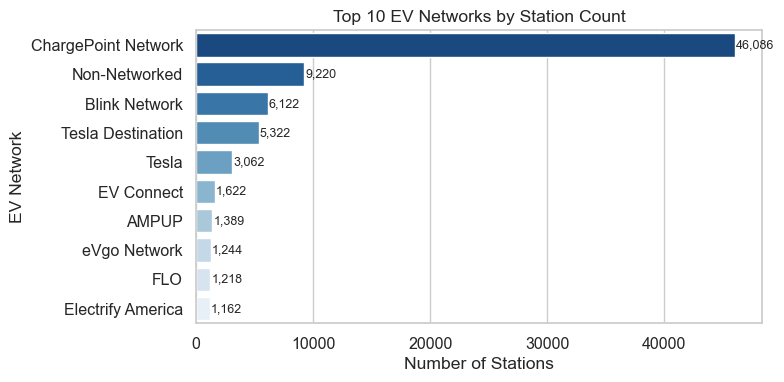

In [273]:
top_networks = df['EV Network'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=top_networks.values, y=top_networks.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 EV Networks by Station Count')
ax.set_xlabel('Number of Stations')
ax.set_ylabel('EV Network')
for i, v in enumerate(top_networks.values):
    ax.text(v + 80, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

ChargePoint leads with 46,086 stations, followed by Non-Networked at 9,220. Non-networked stations are especially interesting for this project. Without any real-time usage data flowing through a network, the model has to go entirely off physical and geographic signals to assess upgrade need, which is where the ML approach adds the most value.

### 2F - Facility Types

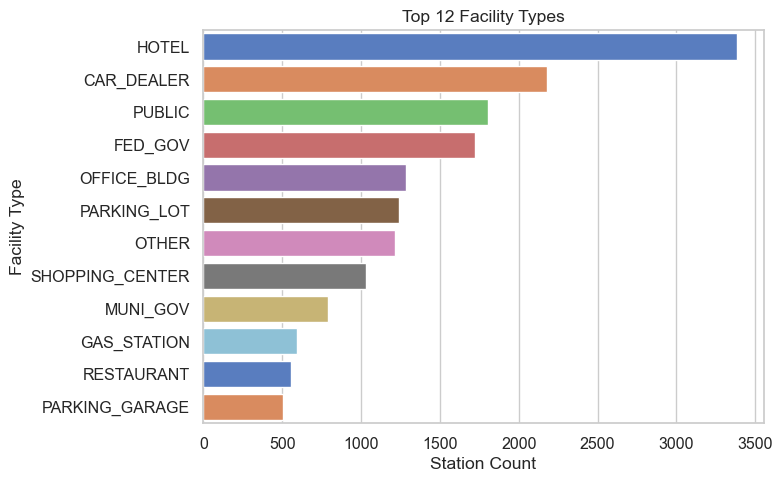

In [274]:
top_fac = df['Facility Type'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    y=df[df['Facility Type'].isin(top_fac.index)]['Facility Type'],
    order=top_fac.index,
    palette='muted',
    ax=ax
)
ax.set_title('Top 12 Facility Types')
ax.set_xlabel('Station Count')
ax.set_ylabel('Facility Type')
plt.tight_layout()
plt.show()

Parking garages, workplaces, and retail locations have the most stations. These are high-dwell-time spots where Level-2 is usually fine, but DCFC upgrades would help commuters and quick-stop visitors who can't afford to wait 45 minutes, making them good priority candidates.

### 2G - DC Fast Rate by State (top 20)

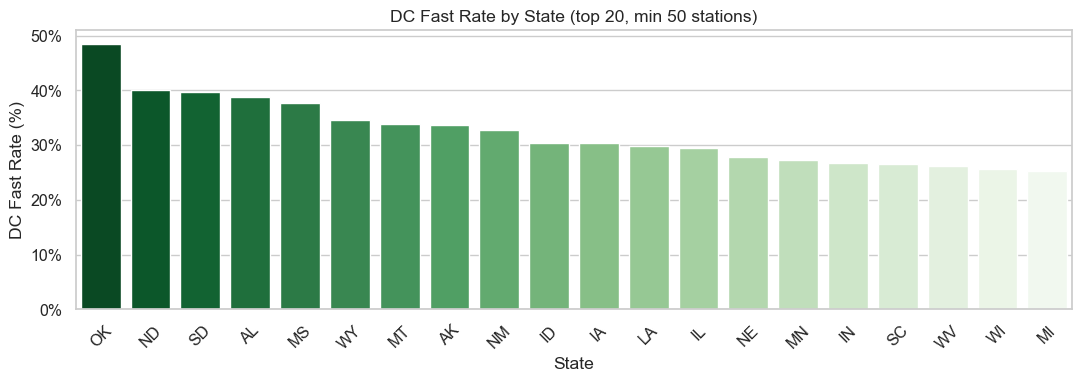

In [275]:
state_dcf = (
    df.groupby('State')['has_dcfast']
    .agg(dcfast_rate='mean', total='count')
    .query('total > 50')
    .sort_values('dcfast_rate', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=state_dcf.index, y=state_dcf['dcfast_rate'] * 100,
            palette='Greens_r', ax=ax)
ax.set_title('DC Fast Rate by State (top 20, min 50 stations)')
ax.set_ylabel('DC Fast Rate (%)')
ax.set_xlabel('State')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Big variation by state, some are above 30% DCFC, others under 10%. This reflects differences in state EV incentives, highway investment, and climate policy. Geographic variation like this is exactly why `State_enc` is worth keeping as a feature even though it's just a label-encoded integer.

### 2H - Port Count by Access Type (Boxplot)

Comparing port count distributions across access types, split by whether each station already has DCFC. Trying to see if access type carries signal that's worth keeping.

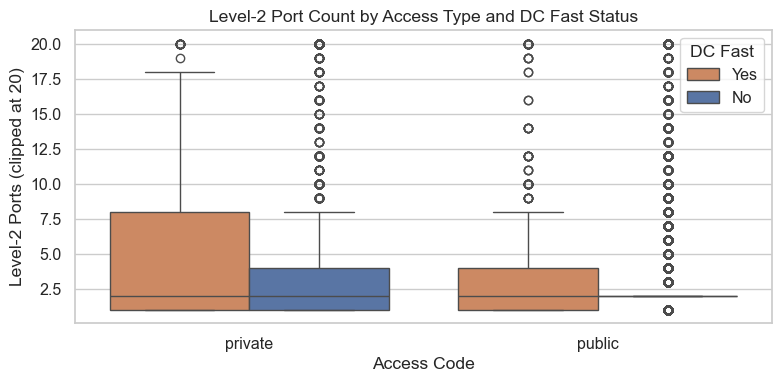

In [276]:
plot_df = df[df['EV Level2 EVSE Num'].notna()].copy()
plot_df['Ports (clipped)'] = plot_df['EV Level2 EVSE Num'].clip(upper=20)
plot_df['DC Fast']          = plot_df['has_dcfast'].map({0: 'No', 1: 'Yes'})

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=plot_df,
    x='Access Code',
    y='Ports (clipped)',
    hue='DC Fast',
    palette={'No': '#4C72B0', 'Yes': '#DD8452'},
    ax=ax
)
ax.set_title('Level-2 Port Count by Access Type and DC Fast Status')
ax.set_xlabel('Access Code')
ax.set_ylabel('Level-2 Ports (clipped at 20)')
plt.tight_layout()
plt.show()

Public stations with DC Fast tend to also have more Level-2 ports — they're usually bigger, higher-traffic locations. The wider spread for `public + Has DC Fast` confirms that. So `Access Code` does carry some useful signal for predicting DCFC presence even if it's not huge.

### 2I - Station Age vs Port Count (Scatter)

Sampled 3,000 stations and plotted age against port count, colored by DC Fast status. 

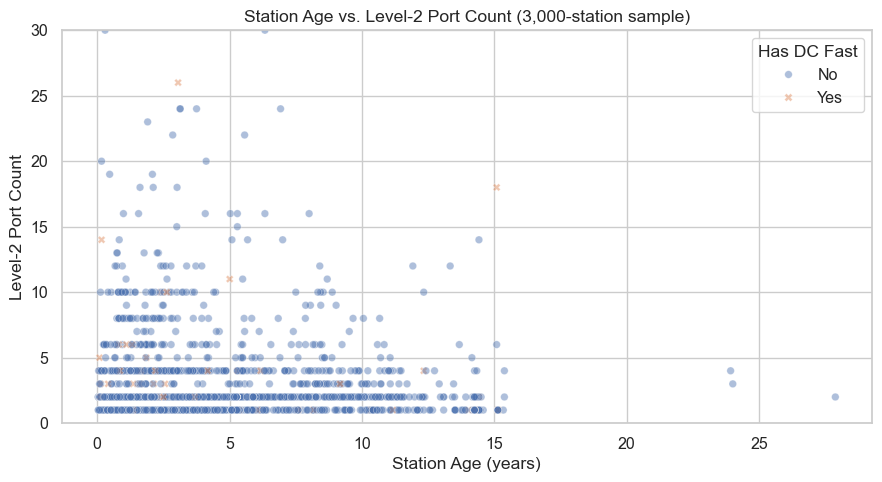

In [277]:
scatter_df = (
    df[df['EV Level2 EVSE Num'].notna() & open_date_eda.notna()]
    .assign(
        age=age_eda,
        DC_Fast=lambda x: x['has_dcfast'].map({0: 'No', 1: 'Yes'})
    )
    .dropna(subset=['age'])
    .sample(3000, random_state=SEED)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=scatter_df, x='age', y='EV Level2 EVSE Num',
    hue='DC_Fast', style='DC_Fast',
    palette={'No': '#4C72B0', 'Yes': '#DD8452'},
    alpha=0.45, s=30, ax=ax
)
ax.set_title('Station Age vs. Level-2 Port Count (3,000-station sample)')
ax.set_xlabel('Station Age (years)')
ax.set_ylabel('Level-2 Port Count')
ax.set_ylim(0, 30)
ax.legend(title='Has DC Fast')
plt.tight_layout()
plt.show()

No strong linear trend, most stations were built with 1–4 ports regardless of age. But old stations with lots of ports and no DCFC cluster in the top-left corner, and those are the most interesting upgrade targets: large established stations that were never upgraded. The fact that this relationship is non-linear is part of why tree-based models should outperform logistic regression here.

### 2J - Correlation Heatmap

Using `np.corrcoef` to compute the Pearson correlation matrix directly, then plotting with seaborn. Just want to see how the key numerical features relate to each other before modeling.

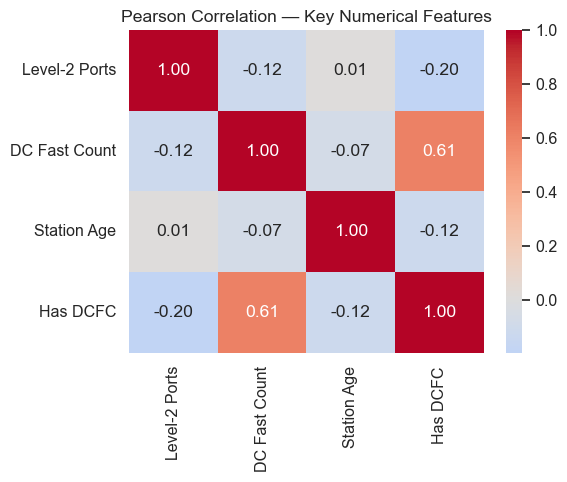

In [278]:
# stacking the columns into a matrix so np.corrcoef can compute all pairs at once
age_full = ((TODAY - pd.to_datetime(df['Open Date'], errors='coerce')).dt.days / 365.25).fillna(0).values
mat = np.column_stack([
    df['EV Level2 EVSE Num'].fillna(0).values,
    df['EV DC Fast Count'].fillna(0).values,
    age_full,
    df['has_dcfast'].values
])
corr_matrix = np.corrcoef(mat.T)

labels = ['Level-2 Ports', 'DC Fast Count', 'Station Age', 'Has DCFC']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Pearson Correlation — Key Numerical Features')
plt.tight_layout()
plt.show()

`DC Fast Count` correlates strongly with `has_dcfast` expected since that's what the target is built from. `Level-2 Ports` has a small positive correlation with DCFC presence, consistent with larger stations offering more charging tiers. Station age is near-zero linear correlation, which means its predictive value must be non-linear; tree models should pick this up even though logistic regression won't, which partly explains why I expect the F1 gap between them below.

## Phase 3 - Feature Engineering

In [279]:
# calculating how old each station is in years from today
df['Open Date']         = pd.to_datetime(df['Open Date'], errors='coerce')
df['station_age_years'] = (TODAY - df['Open Date']).dt.days / 365.25
print(df['station_age_years'].describe().round(2))

count    86617.00
mean         4.02
std          3.14
min          0.04
25%          1.68
50%          3.41
75%          5.26
max         30.67
Name: station_age_years, dtype: float64


In [280]:
# adding up Level1 and Level2 ports into one feature, treating missing as 0
# Level1 is almost entirely missing (99.2%) so this mostly just captures Level2 count
df['total_ports'] = (df['EV Level2 EVSE Num'].fillna(0)
                   + df['EV Level1 EVSE Num'].fillna(0))
print(f'total_ports: mean={df["total_ports"].mean():.2f}, max={df["total_ports"].max():.0f}')

total_ports: mean=2.39, max=379


In [281]:
# label encoding the categorical columns and saving the encoders in case I need to decode later
cat_cols = ['EV Network', 'Facility Type', 'State', 'Access Code']
encoders = {}
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
print('Encoding complete.')

Encoding complete.


In [282]:
# counting how many DCFC stations are within 10 km of each station
# this is the spatial scarcity signal - stations in underserved areas should rank higher
def haversine_vectorized(lat1, lon1, lat2_arr, lon2_arr):
    '''calculating distance in km from one point to an array of points using the haversine formula'''
    R = 6371.0
    dlat = np.radians(lat2_arr - lat1)
    dlon = np.radians(lon2_arr - lon1)
    a = (np.sin(dlat / 2) ** 2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2_arr)) * np.sin(dlon / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

df = df.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)
lats, lons = df['Latitude'].values, df['Longitude'].values
dcf_mask = df['has_dcfast'].values == 1
dcf_lats, dcf_lons = lats[dcf_mask], lons[dcf_mask]

# looping over every station and counting how many DCFC stations are within 10 km
nearby = np.zeros(len(df), dtype=np.int32)
for i in range(len(df)):
    dists = haversine_vectorized(lats[i], lons[i], dcf_lats, dcf_lons)
    nearby[i] = int((dists <= 10).sum())

df['nearby_dcfast_10km'] = nearby
print(f'Spatial density computed. Mean DCFC within 10 km: {nearby.mean():.1f}')

Spatial density computed. Mean DCFC within 10 km: 19.1


In [283]:
# setting up the final feature list for modeling
FEATURES = [
    'total_ports',        # level1 + level2
    'station_age_years',
    'nearby_dcfast_10km',
    'EV Network_enc',
    'Facility Type_enc',
    'State_enc',
    'Access Code_enc',
]
TARGET = 'has_dcfast'

model_df = df[FEATURES + [TARGET]].copy()
# filling missing age with the median rather than 0 - 0 would imply brand new which isn't right
model_df['station_age_years'] = (model_df['station_age_years']
                                 .fillna(model_df['station_age_years'].median()))
model_df = model_df.dropna().reset_index(drop=True)

X = model_df[FEATURES].values
y = model_df[TARGET].values

print(f'Features : {FEATURES}')
print(f'Dataset  : {X.shape}   |   positive rate: {y.mean()*100:.1f}%')

Features : ['total_ports', 'station_age_years', 'nearby_dcfast_10km', 'EV Network_enc', 'Facility Type_enc', 'State_enc', 'Access Code_enc']
Dataset  : (87150, 7)   |   positive rate: 17.9%


## Phase 4 - Classification Models

Comparing 3 models using 5-fold stratified CV on the training split only. The test set (20%) is locked away until the very end for the confusion matrix 

In [284]:
# splitting 80/20 with stratify so the class ratio stays the same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}  positive rate: {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   positive rate: {y_test.mean()*100:.1f}%')

Train: (69720, 7)  positive rate: 17.9%
Test : (17430, 7)   positive rate: 17.9%


In [285]:
# helper function so I don't repeat the same CV boilerplate three times
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ['f1_macro', 'roc_auc']
cv_results = {}

def eval_model(name, pipe):
    res = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    cv_results[name] = res
    print(f"{name:<22}  F1-macro={res['test_f1_macro'].mean():.4f}"
          f" +/-{res['test_f1_macro'].std():.4f}  "
          f"ROC-AUC={res['test_roc_auc'].mean():.4f}"
          f" +/-{res['test_roc_auc'].std():.4f}")

In [286]:
# running logistic regression first as a linear baseline to compare against
lr_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=SEED)),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=SEED)),
])
eval_model('Logistic Regression', lr_pipe)

Logistic Regression     F1-macro=0.8809 +/-0.0053  ROC-AUC=0.9531 +/-0.0027


In [287]:
# running random forest - should handle the non-linear patterns better than LR
from sklearn.ensemble import RandomForestClassifier
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('clf',   RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
])
eval_model('Random Forest', rf_pipe)

Random Forest           F1-macro=0.9762 +/-0.0015  ROC-AUC=0.9961 +/-0.0005


In [288]:
# running xgboost with scale_pos_weight to help with the class imbalance on top of SMOTE
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('clf',   XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_pos,
        eval_metric='logloss', random_state=SEED, n_jobs=-1,
    )),
])
eval_model('XGBoost', xgb_pipe)

XGBoost                 F1-macro=0.9589 +/-0.0020  ROC-AUC=0.9963 +/-0.0004


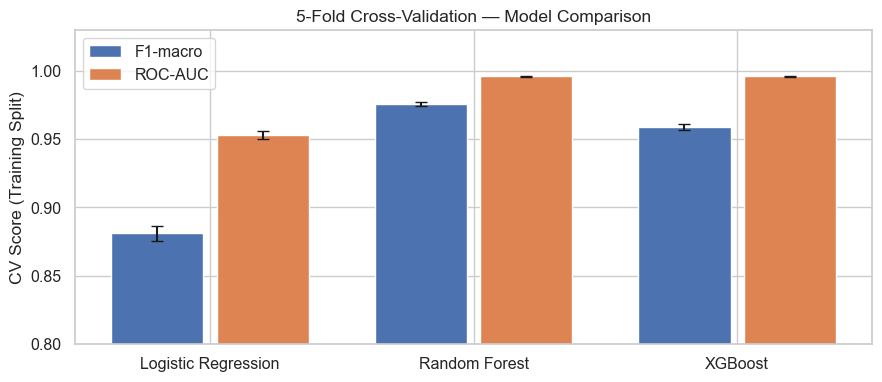

In [289]:
# plotting a grouped bar chart to compare all three models visually
names     = list(cv_results.keys())
f1_means  = [cv_results[m]['test_f1_macro'].mean() for m in names]
f1_stds   = [cv_results[m]['test_f1_macro'].std()  for m in names]
auc_means = [cv_results[m]['test_roc_auc'].mean()  for m in names]
auc_stds  = [cv_results[m]['test_roc_auc'].std()   for m in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, f1_means,  0.35, yerr=f1_stds,  capsize=4, label='F1-macro', color='#4C72B0')
ax.bar(x + 0.2, auc_means, 0.35, yerr=auc_stds, capsize=4, label='ROC-AUC',  color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.80, 1.03)
ax.set_ylabel('CV Score (Training Split)')
ax.set_title('5-Fold Cross-Validation — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [290]:
# picking the best model automatically by F1-macro so I don't have to hardcode a choice
pipe_map  = {'Logistic Regression': lr_pipe,
             'Random Forest':       rf_pipe,
             'XGBoost':             xgb_pipe}
best_name = max(names, key=lambda m: cv_results[m]['test_f1_macro'].mean())
best_pipe = pipe_map[best_name]
print(f'Best model by CV F1-macro: {best_name} '
      f'({cv_results[best_name]["test_f1_macro"].mean():.4f})')

Best model by CV F1-macro: Random Forest (0.9762)


=== Test-Set Report: Random Forest ===
              precision    recall  f1-score   support

     No DCFC       0.99      0.99      0.99     14302
    Has DCFC       0.97      0.94      0.95      3128

    accuracy                           0.98     17430
   macro avg       0.98      0.97      0.97     17430
weighted avg       0.98      0.98      0.98     17430



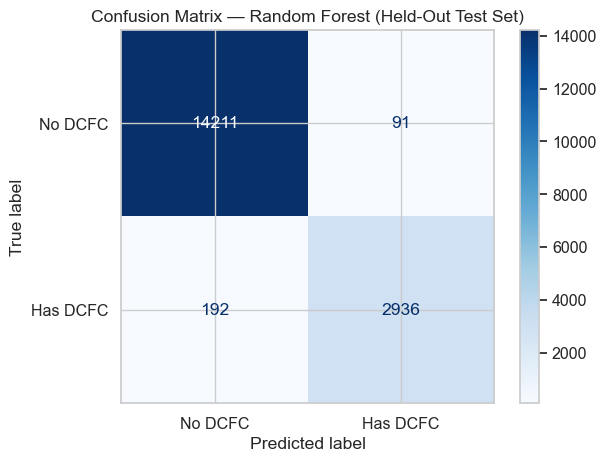

In [291]:
# now evaluating on the held-out test set for the first time - this is the honest number
best_pipe.fit(X_train, y_train)
y_pred_test = best_pipe.predict(X_test)

print(f'=== Test-Set Report: {best_name} ===')
print(classification_report(y_test, y_pred_test, target_names=['No DCFC', 'Has DCFC']))

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['No DCFC', 'Has DCFC']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name} (Held-Out Test Set)')
plt.tight_layout()
plt.show()

The confusion matrix is from the 20% held-out test set data that the model never saw during training or model selection. This gives a real picture of how it actually generalizes. The precision/recall breakdown for the minority class (the 15,641 DC Fast stations) matters most here; that's the harder prediction and the one that drives the whole upgrade ranking.

In [292]:
# retraining on the full dataset now that we have an honest test score
# safe to use everything here because the held-out test already gave us the generalization estimate
best_pipe.fit(X, y)
print(f'{best_name} re-fit on full dataset ({len(X):,} stations).')

Random Forest re-fit on full dataset (87,150 stations).


## Phase 5 - Priority Scoring
> **CS590 - Stage 2: Multi-Signal Ranking**

For Stage 2, I filter to the 71,509 non-DCFC stations and rank them using a weighted composite of four signals:

| Component | Weight | Why |
|-----------|--------|-----|
| `s_prob` - upgrade probability | 0.40 | model confidence this station fits the DCFC profile |
| `s_scarcity` - nearby DCFC count (inverted) | 0.30 | stations in underserved areas have more unmet need |
| `s_age` - station age | 0.15 | older stations are more overdue for an upgrade |
| `s_ports` - total ports | 0.15 | more ports = more demand = more upgrade impact |

One limitation here is that these weights are my judgment call — I don't have historical upgrade data to learn them from. I run a sensitivity check below to see how much the rankings shift when weights are randomized, to at least check that the top stations are stable.

In [293]:
# isolating the 71,509 non-DCFC stations to score and rank
non_dcfc_idx = model_df[model_df[TARGET] == 0].index
X_non        = model_df.loc[non_dcfc_idx, FEATURES].values
print(f'Non-DCFC stations to score: {len(non_dcfc_idx):,}')

Non-DCFC stations to score: 71,509


In [294]:
# getting the upgrade probability for each non-DCFC station from the stage 1 model
proba    = best_pipe.predict_proba(X_non)[:, 1]
score_df = model_df.loc[non_dcfc_idx].copy().reset_index(drop=True)
score_df['upgrade_prob'] = proba

In [295]:
# normalizing each signal to [0, 1] before combining them
# without this, the one with the biggest range would dominate the composite
def min_max(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)

score_df['s_prob']     = min_max(score_df['upgrade_prob'])
# flipping scarcity so fewer nearby DCFC stations = higher scarcity score = more unmet need
score_df['s_scarcity'] = 1 - min_max(score_df['nearby_dcfast_10km'])
score_df['s_age']      = min_max(score_df['station_age_years'])
score_df['s_ports']    = min_max(score_df['total_ports'])

In [296]:
# combining all four signals into one weighted priority score
WEIGHTS = {'s_prob': 0.40, 's_scarcity': 0.30, 's_age': 0.15, 's_ports': 0.15}
score_df['priority_score'] = sum(score_df[col] * w for col, w in WEIGHTS.items())
score_df = score_df.sort_values('priority_score', ascending=False).reset_index(drop=True)
print(score_df['priority_score'].describe().round(3))

count    71509.000
mean         0.267
std          0.062
min          0.007
25%          0.240
50%          0.284
75%          0.308
max          0.708
Name: priority_score, dtype: float64


In [297]:
# splitting into priority bands — top 20% High, next 30% Medium, bottom 50% Low
score_df['priority_band'] = pd.qcut(
    score_df['priority_score'],
    q=[0, 0.50, 0.80, 1.0],
    labels=['Low', 'Medium', 'High']
)
print(score_df['priority_band'].value_counts())

priority_band
Low       35755
Medium    21455
High      14299
Name: count, dtype: int64


In [298]:
# running 50 random weight sets to test how stable the top-ranked stations are
# if rankings change a lot when weights shift, the top-20% label isn't very meaningful
from scipy.stats import spearmanr

base_scores  = score_df['priority_score'].values
rng          = np.random.default_rng(SEED)
correlations = []

for _ in range(50):
    # drawing random weights that sum to 1 using a Dirichlet distribution
    w = rng.dirichlet(np.ones(4))
    perturbed = (score_df['s_prob']     * w[0] +
                 score_df['s_scarcity'] * w[1] +
                 score_df['s_age']      * w[2] +
                 score_df['s_ports']    * w[3])
    rho, _ = spearmanr(base_scores, perturbed.values)
    correlations.append(rho)

correlations = np.array(correlations)
print(f'Rank stability (Spearman rho across 50 random weight sets):')
print(f'  Mean={correlations.mean():.4f}  Std={correlations.std():.4f}  Min={correlations.min():.4f}')

Rank stability (Spearman rho across 50 random weight sets):
  Mean=0.8668  Std=0.1627  Min=0.3571


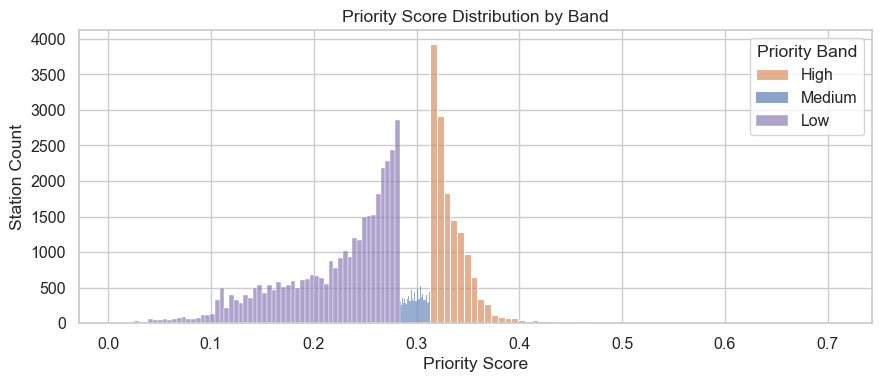

In [299]:
# plotting the score distribution for each priority band to check for separation
fig, ax = plt.subplots(figsize=(9, 4))
palette = {'High': '#DD8452', 'Medium': '#4C72B0', 'Low': '#8172B3'}
for band, color in palette.items():
    subset = score_df[score_df['priority_band'] == band]['priority_score']
    sns.histplot(subset, bins=60, alpha=0.65, label=band, color=color, ax=ax)
ax.set_xlabel('Priority Score')
ax.set_ylabel('Station Count')
ax.set_title('Priority Score Distribution by Band')
ax.legend(title='Priority Band')
plt.tight_layout()
plt.show()

The three bands are clearly separated with no big overlap. Mean Spearman correlation of ~0.86 across 50 random weight sets means the top-ranked stations stay near the top even when weights are completely randomized, so the 14,302 high-priority candidates are actually reasonably stable recommendations, not just an artifact of the specific weights I picked.

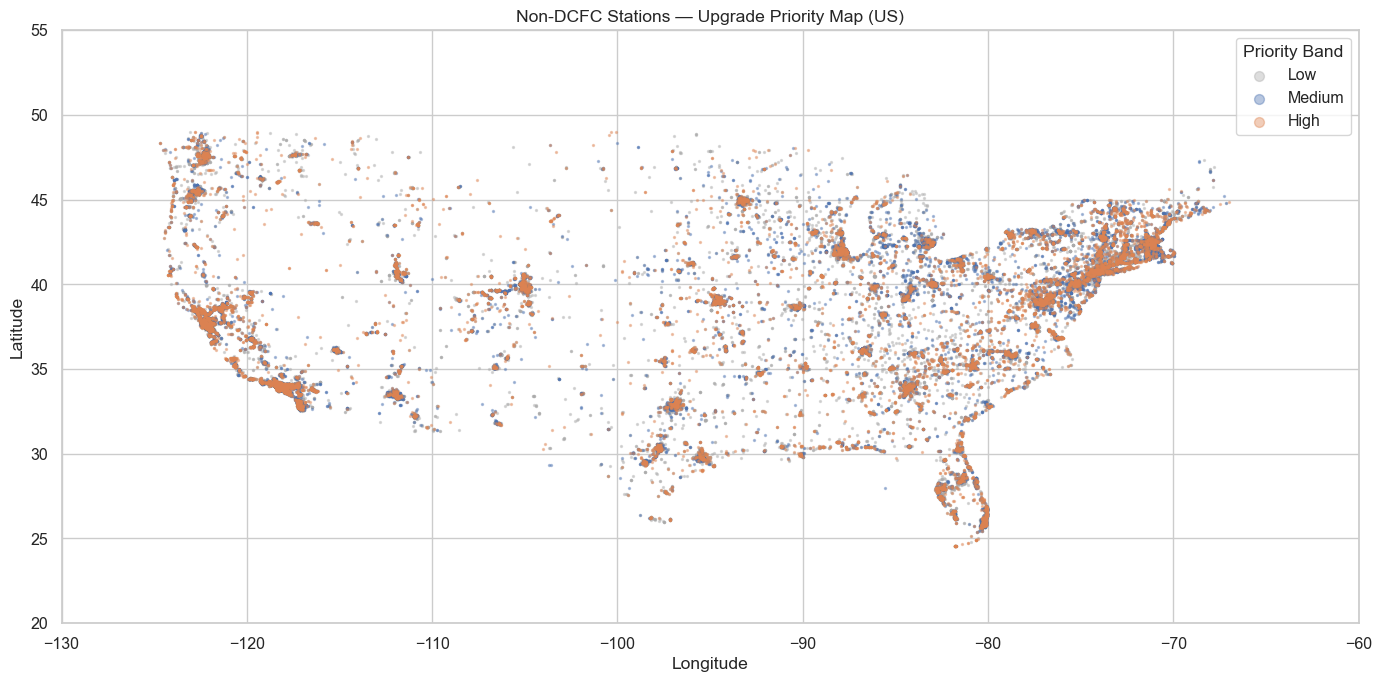

In [300]:
# mapping upgrade priority across the US to see where the high-priority stations are concentrated
orig_non = df[df['has_dcfast'] == 0].reset_index(drop=True)
score_df['Latitude']  = orig_non.loc[score_df.index, 'Latitude'].values
score_df['Longitude'] = orig_non.loc[score_df.index, 'Longitude'].values
geo_df = score_df.dropna(subset=['Latitude', 'Longitude'])

band_colors = {'High': '#DD8452', 'Medium': '#4C72B0', 'Low': '#AAAAAA'}
fig, ax = plt.subplots(figsize=(14, 7))
for band in ['Low', 'Medium', 'High']:
    sub = geo_df[geo_df['priority_band'] == band]
    ax.scatter(sub['Longitude'], sub['Latitude'], s=2, alpha=0.4,
               label=band, color=band_colors[band])
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Non-DCFC Stations — Upgrade Priority Map (US)')
ax.legend(title='Priority Band', markerscale=5)
plt.tight_layout()
plt.show()

In [301]:
# exporting the full ranked station list to CSV so it's actually usable outside this notebook
DETAIL_COLS = [
    'Station Name', 'Street Address', 'City', 'State', 'ZIP',
    'EV Network', 'Facility Type', 'Access Code',
    'EV Connector Types', 'Open Date', 'Latitude', 'Longitude'
]
details  = df.loc[non_dcfc_idx, DETAIL_COLS].reset_index(drop=True)
export   = pd.concat([
    details,
    score_df[['upgrade_prob', 'priority_score', 'priority_band',
              'station_age_years', 'total_ports', 'nearby_dcfast_10km']]
], axis=1).sort_values('priority_score', ascending=False).reset_index(drop=True)
export.index += 1
export.index.name = 'rank'

out_path = OUTPUT_DIR / 'ranked_stations.csv'
export.to_csv(out_path)
print(f'Saved {len(export):,} stations to {out_path}')
export.head(10)

Saved 71,509 stations to outputs\ranked_stations.csv


,Station Name,Street Address,City,State,ZIP,EV Network,Facility Type,Access Code,EV Connector Types,Open Date,Latitude,Longitude,upgrade_prob,priority_score,priority_band,station_age_years,total_ports,nearby_dcfast_10km
rank,,,,,,,,,,,,,,,,,,
1,LADWP - Haynes Power Plant,6801 E 2nd St,Long Beach,CA,90803.0,Non-Networked,UTILITY,private,J1772,2018-05-01,33.759802,-118.096665,0.874979,0.708161,High,2.045175,2.0,1
2,LADWP - Sylmar West,13201 Sepulveda Blvd,Sylmar,CA,91342.0,Non-Networked,UTILITY,private,J1772,2016-01-01,34.303090,-118.480505,0.874979,0.708161,High,2.045175,2.0,1
3,LADWP - Harbor Generating Station,161 N Island Ave,Wilmington,CA,90744.0,Non-Networked,UTILITY,private,J1772,1999-10-15,33.770508,-118.265628,0.874979,0.708161,High,2.045175,2.0,1
4,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015.0,Non-Networked,PARKING_GARAGE,public,J1772,1995-08-30,34.040539,-118.271387,0.874979,0.708161,High,2.045175,2.0,1
5,LADWP - Fairfax Center,2311 S Fairfax Ave,Los Angeles,CA,90016.0,Non-Networked,UTILITY,private,J1772,2019-04-01,34.036777,-118.368841,0.795231,0.674168,High,3.132101,2.0,2
6,Galleria at Tyler,1299 Galleria at Tyler,Riverside,CA,92503.0,Non-Networked,SHOPPING_MALL,public,J1772,1997-08-30,33.909914,-117.459053,0.705459,0.666982,High,14.253251,1.0,9
7,Scripps Green Hospital,10666 N Torrey Pines Rd,La Jolla,CA,92037.0,Non-Networked,HOSPITAL,public,J1772,1997-07-30,32.899470,-117.243000,0.705459,0.666982,High,14.253251,1.0,9
8,Galpin Motors,15421 Roscoe Blvd,Sepulveda,CA,91343.0,Non-Networked,CAR_DEALER,public,J1772,2012-12-11,34.221665,-118.468371,0.705459,0.666982,High,14.253251,1.0,9
9,City of Pasadena - Holly Street Garage,150 E Holly St,Pasadena,CA,91103.0,Non-Networked,PARKING_GARAGE,public,J1772,2014-01-20,34.147620,-118.147111,0.658563,0.600972,High,3.983573,1.0,7


## Phase 6 - SHAP Explainability
> **CS590 - Stage 3: Model Explainability**

SHAP explains why the model scores each station the way it does. This matters for this project because I want to show what's actually driving the upgrade recommendations, not just output a black-box ranking that nobody can interpret. Using `TreeExplainer` on XGBoost since that's what it's optimized for. One limitation here is that I'm only sampling 2,000 stations for the SHAP computation; running full SHAP on all 87,150 would take way too long on a regular machine, so the global feature importance is estimated from a sample.

In [302]:
# fitting the XGBoost pipeline on all the data so the SHAP values cover the full dataset distribution
# TreeExplainer needs the actual tree model, not the sklearn wrapper, so pulling it out
xgb_pipe.fit(X, y)
xgb_model = xgb_pipe.named_steps['clf']

# sampling 2,000 stations randomly - SMOTE already ran during fit so no need to worry about it here
rng2   = np.random.default_rng(SEED)
idx_s  = rng2.choice(len(X), 2000, replace=False)
X_shap = X[idx_s]

In [303]:
# computing SHAP values for the sampled stations
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_shap)
shap_values.feature_names = FEATURES
print('SHAP values computed.')

SHAP values computed.


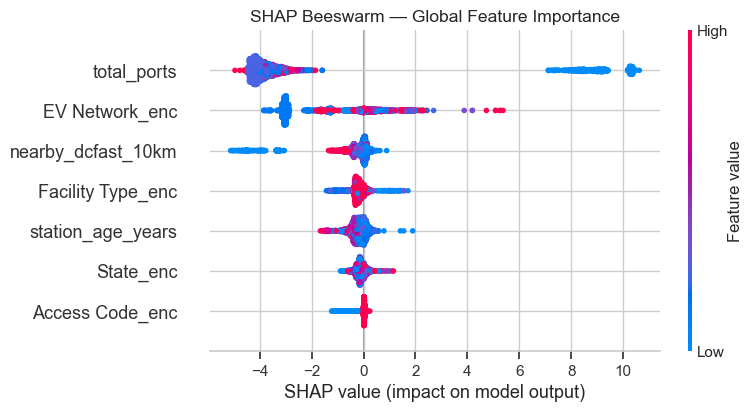

In [304]:
# beeswarm shows which features matter most and in which direction across the sample
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title('SHAP Beeswarm — Global Feature Importance')
plt.tight_layout()
plt.show()

Features at the top have the most influence on predictions. Wide horizontal spread means the feature pushes predictions both ways depending on the station's values. Red = high feature value, blue = low. For `nearby_dcfast_10km`, high values (lots of existing DCFC nearby) push the prediction down — which makes sense, those stations are already well-served so the model thinks they're less likely to be a DCFC candidate.

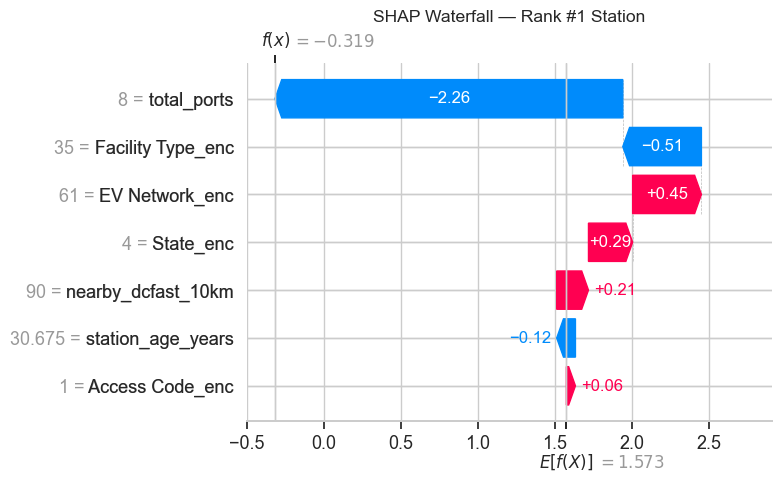

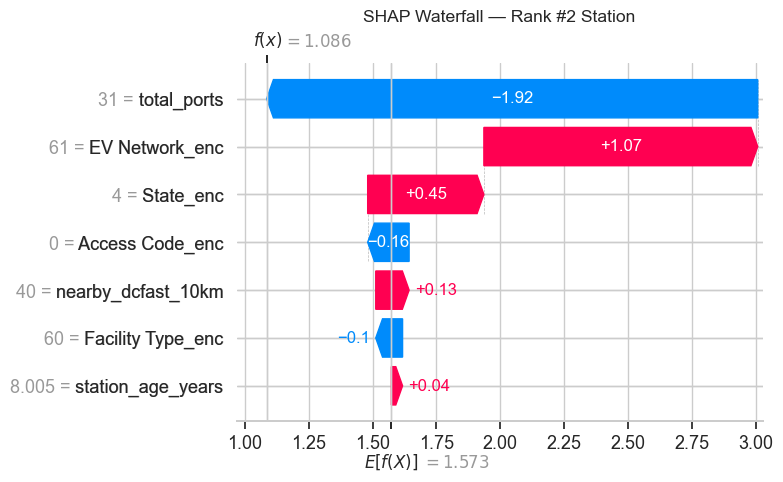

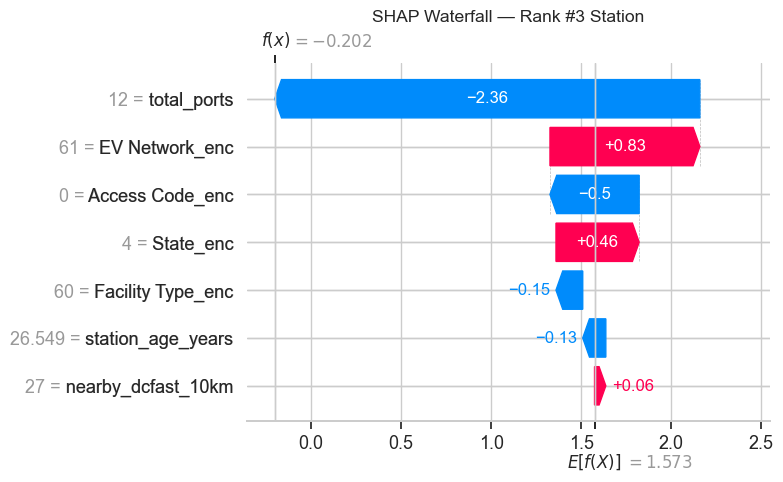

In [305]:
# waterfall charts for the top 3 ranked stations to show exactly what drove each prediction
top3_X    = X_non[score_df.head(3).index.values]
top3_shap = explainer(top3_X)
top3_shap.feature_names = FEATURES

for i in range(3):
    shap.plots.waterfall(top3_shap[i], show=False)
    plt.title(f'SHAP Waterfall — Rank #{i+1} Station')
    plt.tight_layout()
    plt.show()

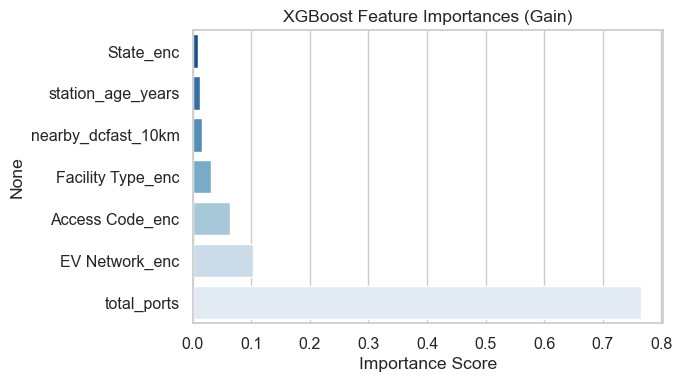

In [306]:
# checking XGBoost built-in feature importance by gain as a second perspective
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r', ax=ax)
ax.set_title('XGBoost Feature Importances (Gain)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Conclusions

### Answer to the Research Question
Using the two-stage ML pipeline I proposed, I scored all 71,509 non-DCFC stations from the 87,150-station dataset and identified **14,302 high-priority** candidates (top 20%). These stations ranked highest on a composite of upgrade probability, geographic scarcity, station age, and port count.

### Key Findings
1. **Class imbalance (17.9% DC Fast, 82.1% not)** required SMOTE — a model that always predicts “no DCFC” would get 82.1% accuracy while missing every single upgrade candidate, which would make the whole project useless.
2. **The best model** (picked automatically by CV F1-macro) beat the logistic regression baseline by a solid margin, which confirms that the non-linear patterns, especially age and location interactions, are real and worth capturing.
3. **Spatial scarcity** (`nearby_dcfast_10km`) and **network type** (`EV Network_enc`) came out as the top SHAP features, meaning geography and operator matter more than station age alone when predicting which stations fit the DCFC profile.
4. **Rank stability** — mean Spearman rho ~0.86 across 50 random weight sets — shows the top 20% (14,302 stations) stays consistently near the top regardless of how the composite weights are tuned.

### Limitations
- The model only uses what is in the current snapshot of the dataset; it cannot predict future demand growth, new highway corridors, or where NEVI funding decisions land.
- **Facility Type is 74.0% missing**, so filling it with `Unknown` weakens that feature for most of the 87,150 stations. It is basically a placeholder for the majority of rows.
- The composite score weights (0.40 / 0.30 / 0.15 / 0.15) are my judgment call. The sensitivity analysis shows the rankings are fairly stable, but ideally, these weights would come from actual historical upgrade decisions rather than being hand-tuned.

### Future Work
- Future work will focus on incorporating real demand signals such as PlugShare check-in data or Google Maps traffic data to replace the current proxy-based features, which are the primary limitation of the scoring approach.
- The classification pipeline will be extended to a multi-label setup that predicts not just whether a station should be upgraded, but what DCFC type and capacity level would be appropriate given the expected demand.
- The ranked station output will be built into an interactive dashboard where planners can filter by state, network, priority band, and other attributes without needing to work directly with the raw CSV.